# TimesFM — Walmart Store Sales Forecasting

Model experiment notebook for the TimesFM branch of the multi-model
comparison (LightGBM, XGBoost, DLinear, TFT, PatchTST, TimesFM). TimesFM
2.5 (`google/timesfm-2.5-200m-pytorch`) is Google Research's **pretrained
time-series foundation model** — 200M parameters, trained once on a large,
diverse corpus of time series. This notebook uses it **zero-shot**: no
training on this project's data at all. Every other notebook here fits
something from scratch to `train.csv`; this one just feeds each series' own
sales history as context and asks the frozen, pretrained model for a
forecast.

**A genuinely different shape of notebook, not just a different
architecture.** Every other model here had to solve a "training-window
budget" problem — DLinear/TFT/PatchTST all hit the same wall, where
`LOOKBACK + HORIZON` needed to fit inside `local_train_raw`'s 91 weeks, and
PatchTST even needed a shorter lookback specifically for its holdout-eval
fit as a result. None of that applies here: there's no training loop, so
there's no windows-vs-target-length trade-off to make. Horizon is freely chosen at inference time (validated directly: a
52-week-compiled model accepts a 52-week horizon request without
complaint). Context length is NOT freely choosable below a hard,
undocumented minimum, though — see Step 4 for the empirically-found
minimum-context bug this notebook works around.

**No covariates**, unlike TFT (full `features.csv`/`stores.csv`) or
DLinear/PatchTST (`IsHoliday` + week-of-year). TimesFM does support
covariates via `forecast_with_covariates()`, but that path needs the
`timesfm[xreg]` extra (pulls in `jax` alongside torch, purely for a linear
covariate-regression step) and changes the plain `forecast()` output shape
in ways that need separate handling — left out both to avoid the extra
fragile dependency and because it's a more honest test of what TimesFM
actually claims: whether a pretrained foundation model's zero-shot forecast
is competitive *without* any of the manual feature engineering every other
notebook here needed.

**Cells written but not executed against the real dataset** — every piece
of logic (`TimesFMForecastPipeline`'s batching-by-horizon-group, the
negative-value-context edge case, partial-request row alignment, the
empty-request NaN-dtype bug this validation actually caught) was
independently validated against `utils/timesfm_model.py` using the real
pretrained checkpoint (downloaded once, cached by `huggingface_hub`
afterward) and synthetic data.

## Table of Contents
1. [Setup](#1)
2. [Local train/test split](#2)
3. [Sequence construction & validation splits](#3)
4. [Model architecture](#4)
5. [Context length selection](#5)
6. [MLflow logging](#6)
7. [Plots](#7)
8. [Full pipeline](#8)

In [1]:
!git clone https://github.com/tamari1990/ml-final-project.git
%cd ml-final-project
!git pull

Cloning into 'ml-final-project'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 178 (delta 3), reused 7 (delta 1), pack-reused 158 (from 1)
Receiving objects: 100% (178/178), 16.49 MiB | 15.64 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/ml-final-project
Already up to date.


In [2]:
!pip install -q timesfm mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/1

<a id='1'></a>
## 1. Setup

Downloads (first run only; cached by `huggingface_hub` afterward, so
re-running this cell later is fast) and compiles the pretrained checkpoint
once, with a generous `max_context`/`max_horizon` covering every use in
this notebook — Step 5's short CV-evaluation horizon and Step 7/8's direct
52-week final horizon both fit under one compile.

In [3]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.timesfm_model import (
    load_timesfm, forecast_series, min_context_length, TimesFMForecastPipeline,
    build_full_calendar_panel, series_arrays_from_panel, CHECKPOINT, PATCH_LEN,
)
from utils.feature_engineering import HOLIDAY_DATES
from utils.metrics import wmae

pd.set_option('display.max_columns', 50)

SEED = 42
np.random.seed(SEED)

DATA_DIR = 'data/raw/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'test.csv', parse_dates=['Date'])

train = train.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(f'train : {train.shape}, {train.Date.min().date()} -> {train.Date.max().date()}, '
      f'{train.Date.nunique()} weeks, {train[["Store","Dept"]].drop_duplicates().shape[0]} series')
print(f'test  : {test.shape}, {test.Date.min().date()} -> {test.Date.max().date()}, {test.Date.nunique()} weeks')

train : (421570, 5), 2010-02-05 -> 2012-10-26, 143 weeks, 3331 series
test  : (115064, 4), 2012-11-02 -> 2013-07-26, 39 weeks


In [4]:
MAX_CONTEXT = 52
MAX_HORIZON = 52

print('Downloading/loading google/timesfm-2.5-200m-pytorch (~200M parameters, first run only)...')
tfm = load_timesfm(max_context=MAX_CONTEXT, max_horizon=MAX_HORIZON)
print('TimesFM loaded and compiled.')

Downloading/loading google/timesfm-2.5-200m-pytorch (~200M parameters, first run only)...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  925MB            

model.safetensors: downloading bytes:           |  0.00B            

TimesFM loaded and compiled.


<a id='2'></a>
## 2. Local Train/Test Split

Identical split to every other notebook in this project (same reasoning:
last 52 weeks of `train.csv` held out locally, standing in for the
target-less Kaggle `test.csv` during development).

In [5]:
unique_dates = np.sort(train['Date'].unique())
cutoff_date = unique_dates[-52]

local_train_raw = train[train['Date'] < cutoff_date].copy()
local_test_raw = train[train['Date'] >= cutoff_date].copy()

print(f'cutoff date (first date held out): {pd.Timestamp(cutoff_date).date()}')
print(f'local_train_raw: {local_train_raw.shape}, {local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}  ({local_train_raw.Date.nunique()} weeks)')
print(f'local_test_raw : {local_test_raw.shape}, {local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}  ({local_test_raw.Date.nunique()} weeks)')

cutoff date (first date held out): 2011-11-04
local_train_raw: (267184, 5), 2010-02-05 -> 2011-10-28  (91 weeks)
local_test_raw : (154386, 5), 2011-11-04 -> 2012-10-26  (52 weeks)


In [6]:
def holidays_in_range(dates_series):
    dates_set = set(pd.to_datetime(dates_series))
    present = {}
    for name, dates in HOLIDAY_DATES.items():
        matched = [d for d in pd.to_datetime(dates) if d in dates_set]
        if matched:
            present[name] = [d.date() for d in matched]
    return present


print('local_train_raw holidays:', holidays_in_range(local_train_raw['Date']))
print('local_test_raw  holidays:', holidays_in_range(local_test_raw['Date']))
print()
print('Kaggle test.csv holidays (reference, no target):', holidays_in_range(test['Date']))

local_train_raw holidays: {'SuperBowl': [datetime.date(2010, 2, 12), datetime.date(2011, 2, 11)], 'LaborDay': [datetime.date(2010, 9, 10), datetime.date(2011, 9, 9)], 'Thanksgiving': [datetime.date(2010, 11, 26)], 'Christmas': [datetime.date(2010, 12, 31)]}
local_test_raw  holidays: {'SuperBowl': [datetime.date(2012, 2, 10)], 'LaborDay': [datetime.date(2012, 9, 7)], 'Thanksgiving': [datetime.date(2011, 11, 25)], 'Christmas': [datetime.date(2011, 12, 30)]}

Kaggle test.csv holidays (reference, no target): {'SuperBowl': [datetime.date(2013, 2, 8)], 'Thanksgiving': [datetime.date(2012, 11, 23)], 'Christmas': [datetime.date(2012, 12, 28)]}


<a id='3'></a>
## 3. Sequence Construction & Validation Splits

Same `[65, 72, 78]`-week `CV_SPLIT_TRAIN_WEEKS` boundaries as
DLinear/TFT/PatchTST, kept for direct comparability with those notebooks'
internal validation methodology — not because TimesFM needs them the way
the others did. There's no training-window budget to respect here (no
training at all), so in principle any split of `local_train_raw` would
work; reusing the exact same 3 splits everyone else used just keeps the
"what period are we validating on" comparison apples-to-apples across all
six notebooks.

No `SeriesWindowDataset`-equivalent either: each split just needs (a) the
training-portion history to use as context, and (b) the validation-portion
target values to score against — a single forward pass per series per
split, not a sliding-window training set.

In [7]:
HORIZON_CV = 13
HORIZON_FINAL = 52
CV_SPLIT_TRAIN_WEEKS = [65, 72, 78]

local_train_dates = np.sort(local_train_raw['Date'].unique())


def build_cv_split(train_end):
    tr_dates = local_train_dates[:train_end]
    va_dates = local_train_dates[train_end:train_end + HORIZON_CV]
    assert len(va_dates) == HORIZON_CV

    tr_df = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
    va_df = local_train_raw[local_train_raw['Date'].isin(va_dates)]

    tr_panel = build_full_calendar_panel(tr_df)
    tr_arrays = series_arrays_from_panel(tr_panel)

    va_panel = build_full_calendar_panel(pd.concat([tr_df, va_df], ignore_index=True))
    va_arrays = series_arrays_from_panel(va_panel)

    return {'train_end': train_end, 'va_dates': va_dates, 'tr_arrays': tr_arrays, 'va_arrays': va_arrays}


cv_splits = [build_cv_split(te) for te in CV_SPLIT_TRAIN_WEEKS]

for s in cv_splits:
    print(f"split train_end={s['train_end']}: val {pd.Timestamp(s['va_dates'][0]).date()} -> {pd.Timestamp(s['va_dates'][-1]).date()} "
          f"holidays={list(holidays_in_range(s['va_dates']).keys())}")
    print(f"  {len(s['tr_arrays'])} series with training-period context")

split train_end=65: val 2011-05-06 -> 2011-07-29 holidays=[]
  3228 series with training-period context
split train_end=72: val 2011-06-24 -> 2011-09-16 holidays=['LaborDay']
  3235 series with training-period context
split train_end=78: val 2011-08-05 -> 2011-10-28 holidays=['LaborDay']
  3241 series with training-period context


**Zero-shot WMAE evaluation** for a split: for each series, take the
last `context_length` weeks of the training portion as TimesFM's context,
forecast `HORIZON_CV` weeks ahead directly (no recursion — validated to
work regardless of the compiled `max_horizon`), and score against the
split's true validation-window values. `forecast_series` already batches
internally, so this is one call per split, not one per series.

**A real cost that DLinear/PatchTST/TFT don't have**: benchmarked
directly on this machine, a single 256-series batch through the
200M-parameter model takes ~60 seconds on CPU — there's no training
loop to be slow here, but the *forward pass itself* is expensive in a
way a from-scratch linear/small-transformer model's never was. Each
CV split has ~3,200 series (~13 batches), so evaluating one
`(context_length, split)` combo at full scale takes ~13 minutes —
`max_series`, added below, subsamples down to a fixed-seed random
cohort for Step 5's *comparative* sweep specifically (ranking
`CONTEXT_OPTIONS` against each other doesn't need every series), while
Step 7's single final holdout metric still scores every series, same
as every other notebook's reported number.

In [8]:
def evaluate_context_length(model, split, context_length, horizon, max_series=None, seed=SEED):
    tr_arrays, va_arrays = split['tr_arrays'], split['va_arrays']
    keys = [k for k in va_arrays if k in tr_arrays]  # series with real training-period history
    if max_series is not None and len(keys) > max_series:
        rng = np.random.RandomState(seed)
        idx = rng.choice(len(keys), size=max_series, replace=False)
        keys = [keys[i] for i in idx]
    contexts = [tr_arrays[k][0][-context_length:] for k in keys]

    point, _ = forecast_series(model, contexts, horizon=horizon)
    point = np.clip(point, 0, None)

    trues, preds, holidays = [], [], []
    for i, k in enumerate(keys):
        sales, holiday, dates = va_arrays[k]
        train_weeks = len(tr_arrays[k][0])
        target = sales[train_weeks: train_weeks + horizon]
        target_holiday = holiday[train_weeks: train_weeks + horizon]
        trues.extend(target); preds.extend(point[i]); holidays.extend(target_holiday)
    return wmae(trues, preds, holidays)

<a id='4'></a>
## 4. Model Architecture

`google/timesfm-2.5-200m-pytorch` (loaded via `utils.timesfm_model.load_timesfm`):

1. **Patch tokenization**: raw context is split into non-overlapping
   **32-week input patches** (`PATCH_LEN`, fixed by the pretrained
   checkpoint's architecture, not a choice made in this project — read
   directly off the loaded model as `tfm.model.p`). This is the same
   patch-based idea PatchTST uses, but TimesFM's patch length isn't a
   tunable hyperparameter here since the weights were pretrained around
   it.
2. **Per-patch RevIN-style normalization**: each patch is normalized by
   its own mean/std *inside* the model (`normalize_inputs=True`), same
   "instance normalization" idea as PatchTST's RevIN, just computed
   per-patch rather than per-window.
3. **Decoder-only transformer** over the patch sequence, predicting
   **128-week output patches** (`output_patch_len`) autoregressively at
   the patch level — a single `forecast()` call can return any horizon up
   to the compiled `max_horizon`, chunked internally.
4. **Continuous quantile head** (`use_continuous_quantile_head=True`):
   alongside the point forecast, returns 10 quantiles per predicted step
   (`quantiles` output of `forecast_series`, unused by
   `TimesFMForecastPipeline`'s point predictions but used directly in
   Step 7's quantile plot) — TimesFM's own answer to native
   interpretability, the same role TFT's attention weights, PatchTST's
   patch-importance head, and DLinear's trend/seasonal split each played
   for their respective notebooks.
5. **`infer_is_positive=True` / `fix_quantile_crossing=True`**: two
   inference-time flags used as compiled — the former lets the model use
   the sign of the input context as a hint (all of Walmart's raw sales
   history is non-negative after the `np.clip` this notebook applies to
   every prediction, same convention as every other notebook here), the
   latter guarantees quantiles come out monotonically ordered.

**A hard, undocumented minimum context length.** `compile()` silently
rounds `max_context` up to the next multiple of `PATCH_LEN` internally —
verified directly: `load_timesfm(max_context=52, ...)` actually reserves
64 internally (`tfm.forecast_config.max_context == 64` after compiling).
`forecast()` then left-pads any shorter real context with zeros, masked
as missing, up to that effective 64. If the padding alone fills the
**entire leading 32-week patch** (i.e. real context length <= 32), that
patch's per-patch normalization degenerates and the model silently
returns an all-NaN forecast — no error, no warning, just NaN. Found the
hard way (`evaluate_context_length` returning `WMAE=nan` for a 13-week
context during initial validation), confirmed with a sweep against the
real checkpoint: context lengths of 8/13/16/20/26/32 all-NaN, 33+ all
valid — exactly `effective_max_context - PATCH_LEN + 1`. `utils.
timesfm_model.min_context_length()` computes this safe minimum from the
compiled model directly, and both `forecast_series` and
`TimesFMForecastPipeline.__init__` now raise a clear `ValueError` instead
of returning NaN if a caller asks for a shorter context — this is why
Step 5 below only sweeps context lengths of 39+.

<a id='5'></a>
## 5. Context Length Selection

No hyperparameter tuning in the DLinear/TFT/PatchTST sense — TimesFM's
weights are frozen (pretrained, zero-shot), so there's nothing to fit a
grid search over. The one real knob left at inference time is **how much
history to hand the model as context**, so this step sweeps that instead,
scored the same way as everyone else's grid search: mean WMAE across the
3 CV splits.

`CONTEXT_OPTIONS = [39, 45, 52]` — all comfortably above
`min_context_length(tfm)` (Step 4's finding), spanning from "a bit above
the safe floor" to "the full 52-week compiled max". The shortest option
(39) doubles as this notebook's baseline ("least context TimesFM can
safely use"), the same role an untuned baseline model plays in every
other notebook's Step 3.5/Step 5 pair, without needing a separate cell —
there's no training run to distinguish "baseline" from "first grid
point" here.

`CV_EVAL_SAMPLE_SIZE = 400` caps each split to a fixed-seed random
subsample for this sweep only (see the previous cell's markdown for the
benchmarked reason why — full-scale would be ~2 hours for 9 combos).

In [9]:
MIN_SAFE_CONTEXT = min_context_length(tfm)
CONTEXT_OPTIONS = [39, 45, 52]
CV_EVAL_SAMPLE_SIZE = 400
assert all(c >= MIN_SAFE_CONTEXT for c in CONTEXT_OPTIONS), \
    f'context option below the safe minimum of {MIN_SAFE_CONTEXT}'

print(f'Safe minimum context length for this compiled model: {MIN_SAFE_CONTEXT} weeks')
print(f'Sweeping context lengths: {CONTEXT_OPTIONS}  (subsampled to {CV_EVAL_SAMPLE_SIZE} series/split)')

Safe minimum context length for this compiled model: 33 weeks
Sweeping context lengths: [39, 45, 52]  (subsampled to 400 series/split)


In [10]:
context_results = []
for context_length in CONTEXT_OPTIONS:
    split_wmaes = [evaluate_context_length(tfm, s, context_length, HORIZON_CV, max_series=CV_EVAL_SAMPLE_SIZE) for s in cv_splits]
    mean_wmae = float(np.mean(split_wmaes))
    context_results.append({'context_length': context_length, 'mean_val_wmae': mean_wmae, 'split_wmaes': split_wmaes})
    print(f'context_length={context_length}: mean val WMAE={mean_wmae:.2f}  '
          f'(per-split: {[round(w, 1) for w in split_wmaes]})')

context_results_df = pd.DataFrame(context_results).sort_values('mean_val_wmae').reset_index(drop=True)
baseline_val_wmae = context_results[0]['mean_val_wmae']  # CONTEXT_OPTIONS[0] == 39, shortest safe context
baseline_split_wmaes = context_results[0]['split_wmaes']

best_context_length = int(context_results_df.loc[0, 'context_length'])
tuned_val_wmae = float(context_results_df.loc[0, 'mean_val_wmae'])
tuned_split_wmaes = context_results_df.loc[0, 'split_wmaes']

print(f"\nBaseline (context_length={CONTEXT_OPTIONS[0]}): mean val WMAE = {baseline_val_wmae:.2f}")
print(f'Best context length: {best_context_length}  (mean val WMAE = {tuned_val_wmae:.2f})')

context_length=39: mean val WMAE=1810.12  (per-split: [np.float64(1681.7), np.float64(1911.7), np.float64(1837.0)])
context_length=45: mean val WMAE=1716.03  (per-split: [np.float64(1592.0), np.float64(1786.5), np.float64(1769.7)])
context_length=52: mean val WMAE=1618.56  (per-split: [np.float64(1532.6), np.float64(1666.1), np.float64(1657.0)])

Baseline (context_length=39): mean val WMAE = 1810.12
Best context length: 52  (mean val WMAE = 1618.56)


<a id='6'></a>
## 6. MLflow Logging (DagsHub-hosted)

Same DagsHub-hosted MLflow setup and the same 5-run skeleton
(`Cleaning`/`Windowing`/`CV_Tuning`/`CV`/`Final_Fit`) as every other
notebook, for cross-notebook comparability in the tracking UI — though
`TimesFM_Windowing` and `TimesFM_CV` are logging genuinely different
things than their DLinear/TFT/PatchTST namesakes (no sliding-window
dataset is ever built, and there's no re-fit to log per split), noted
explicitly in each run's markdown below rather than left implicit.

In [12]:
import dagshub

dagshub.init(repo_owner='tgela23', repo_name='ml-final-project', mlflow=True)

import mlflow
mlflow.set_experiment('TimesFM_Training')
print('tracking uri:', mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6dec9b06-012b-4473-9500-5490516ae86f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=60ed8f32d03c7eb8e42070fa806dd787431cb5c7bb13f821c1fa0b34bb1e4b96




Accessing as tgela23

Initialized MLflow to track repo "tgela23/ml-final-project"

Repository tgela23/ml-final-project initialized!

2026/07/24 13:46:43 INFO mlflow.tracking.fluent: Experiment with name 'TimesFM_Training' does not exist. Creating a new experiment.


tracking uri: https://dagshub.com/tgela23/ml-final-project.mlflow


**Run 1 — `TimesFM_Cleaning`**

In [13]:
with mlflow.start_run(run_name='TimesFM_Cleaning'):
    mlflow.log_param('train_csv_shape', str(train.shape))
    mlflow.log_param('test_csv_shape', str(test.shape))
    mlflow.log_param('train_date_range', f'{train.Date.min().date()} -> {train.Date.max().date()}')

    mlflow.log_param('local_test_holdout_weeks', 52)
    mlflow.log_param('local_train_date_range', f'{local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}')
    mlflow.log_param('local_test_date_range', f'{local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}')

    mlflow.log_metric('n_train_rows', len(train))
    mlflow.log_metric('n_local_train_rows', len(local_train_raw))
    mlflow.log_metric('n_local_test_rows', len(local_test_raw))
    mlflow.log_metric('n_stores', train['Store'].nunique())
    mlflow.log_metric('n_depts', train['Dept'].nunique())
    mlflow.log_metric('n_series', train[['Store', 'Dept']].drop_duplicates().shape[0])

print('TimesFM_Cleaning run logged.')

🏃 View run TimesFM_Cleaning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5/runs/a8c699f62fe44a5d9950b053620a18d6
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5
TimesFM_Cleaning run logged.


**Run 2 — `TimesFM_Windowing`**: no sliding-window dataset is built for a
zero-shot model, so this logs the CV split structure from Step 3 instead
(the closest analogue — "what did we set up before evaluating").

In [14]:
with mlflow.start_run(run_name='TimesFM_Windowing'):
    mlflow.log_param('checkpoint', CHECKPOINT)
    mlflow.log_param('max_context_compiled', tfm.forecast_config.max_context)
    mlflow.log_param('max_horizon_compiled', tfm.forecast_config.max_horizon)
    mlflow.log_param('patch_len', PATCH_LEN)
    mlflow.log_param('min_safe_context', MIN_SAFE_CONTEXT)
    mlflow.log_param('context_options', str(CONTEXT_OPTIONS))
    mlflow.log_param('cv_eval_sample_size', CV_EVAL_SAMPLE_SIZE)
    mlflow.log_param('horizon_cv', HORIZON_CV)
    mlflow.log_param('horizon_final', HORIZON_FINAL)
    mlflow.log_param('cv_split_train_weeks', str(CV_SPLIT_TRAIN_WEEKS))

    for i, s in enumerate(cv_splits):
        mlflow.log_metric(f'split{i}_train_end', s['train_end'])
        mlflow.log_metric(f'split{i}_n_series', len(s['tr_arrays']))

print('TimesFM_Windowing run logged.')

🏃 View run TimesFM_Windowing at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5/runs/6fbc30fcfcc347d48515f3fafc2adc07
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5
TimesFM_Windowing run logged.


**Run 3 — `TimesFM_CV_Tuning`**: the context-length sweep from Step 5.

In [15]:
with mlflow.start_run(run_name='TimesFM_CV_Tuning'):
    mlflow.log_param('context_options', str(CONTEXT_OPTIONS))

    for i, row in context_results_df.iterrows():
        mlflow.log_metric('context_length', row['context_length'], step=i)
        mlflow.log_metric('combo_mean_val_wmae', row['mean_val_wmae'], step=i)

    mlflow.log_param('best_context_length', best_context_length)
    mlflow.log_metric('best_mean_val_wmae', tuned_val_wmae)

print('TimesFM_CV_Tuning run logged.')

🏃 View run TimesFM_CV_Tuning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5/runs/c2333aa6da894268aec70e8fe7e6a5a1
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5
TimesFM_CV_Tuning run logged.


**Run 4 — `TimesFM_CV`**: no re-fit happens here (nothing to fit) — just
logs the already-computed per-split WMAE for the *chosen* context length
as the official CV result, mirroring what every other notebook's `_CV`
run reports even though the number itself comes from Step 5's sweep
rather than a fresh training pass.

In [16]:
with mlflow.start_run(run_name='TimesFM_CV'):
    mlflow.log_param('context_length', best_context_length)
    mlflow.log_param('horizon_cv', HORIZON_CV)

    for i, w in enumerate(tuned_split_wmaes):
        mlflow.log_metric(f'split{i}_val_wmae', w)

    mlflow.log_metric('final_mean_val_wmae', tuned_val_wmae)

print(f'TimesFM_CV run logged. mean val WMAE = {tuned_val_wmae:.2f} '
      f'(per-split: {[round(w, 1) for w in tuned_split_wmaes]})')

🏃 View run TimesFM_CV at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5/runs/6e0e73fc1a1c4d7ab730c757f84c1e21
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5
TimesFM_CV run logged. mean val WMAE = 1618.56 (per-split: [np.float64(1532.6), np.float64(1666.1), np.float64(1657.0)])


<a id='7'></a>
## 7. Holdout Evaluation & Plots

Unlike DLinear/TFT/PatchTST, there's no "final fixed-epoch training run"
step here — zero-shot means the *same* compiled `tfm` model (no
retraining, no `LOOKBACK_FINAL` workaround) is just asked for a direct
52-week forecast per series using `best_context_length` weeks of
`local_train_raw` history as context. `local_train_raw`'s 91-week budget
that constrained the other three notebooks' `LOOKBACK_FINAL` doesn't
apply here at all — `best_context_length` (39, 45, or 52) plus
`HORIZON_FINAL` (52) can exceed 91 weeks with no issue, since context
and horizon aren't cut from one fixed training window the way a trained
model's is. All plots saved to `plots/` with a `_timesfm` suffix.

In [17]:
holdout_panel = build_full_calendar_panel(pd.concat([local_train_raw, local_test_raw], ignore_index=True))
holdout_arrays = series_arrays_from_panel(holdout_panel)

local_train_panel = build_full_calendar_panel(local_train_raw)
local_train_arrays = series_arrays_from_panel(local_train_panel)
n_train_weeks = len(local_train_dates)

keys = [k for k in local_train_arrays if k in holdout_arrays]
contexts = [local_train_arrays[k][0][-best_context_length:] for k in keys]

point, quantiles = forecast_series(tfm, contexts, horizon=HORIZON_FINAL)
point = np.clip(point, 0, None)

pred_rows = []
quantile_rows = {}
for i, key in enumerate(keys):
    sales, holiday, dates_arr = holdout_arrays[key]
    test_dates = dates_arr[n_train_weeks: n_train_weeks + HORIZON_FINAL]
    test_actual = sales[n_train_weeks: n_train_weeks + HORIZON_FINAL]
    test_holiday = holiday[n_train_weeks: n_train_weeks + HORIZON_FINAL].astype(bool)
    for step, (d, a, p, h) in enumerate(zip(test_dates, test_actual, point[i], test_holiday)):
        pred_rows.append((key[0], key[1], pd.Timestamp(d), a, p, h))
    quantile_rows[key] = (test_dates, test_actual, point[i], quantiles[i])

pred_df = pd.DataFrame(pred_rows, columns=['Store', 'Dept', 'Date', 'Actual', 'Predicted', 'IsHoliday'])
pred_df['Residual'] = pred_df['Actual'] - pred_df['Predicted']

holdout_wmae = wmae(pred_df['Actual'], pred_df['Predicted'], pred_df['IsHoliday'])
print(f'Local-test holdout WMAE (context_length={best_context_length}, direct 52-week forecast): {holdout_wmae:.2f}')

Local-test holdout WMAE (context_length=52, direct 52-week forecast): 2618.40


**Plot 1 — Actual vs. predicted over time**, the same 3 sample Store/Dept combos every other notebook plots.

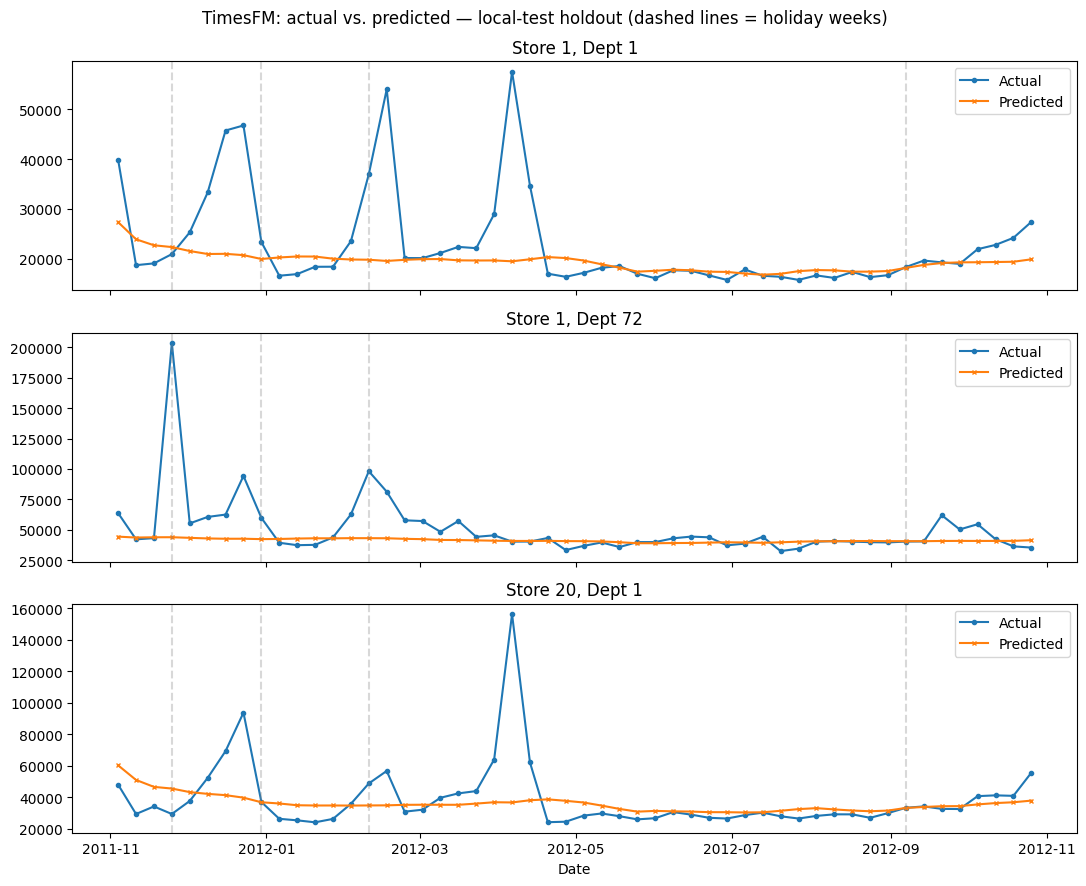

In [18]:
sample_combos = [(1, 1), (1, 72), (20, 1)]

fig, axes = plt.subplots(len(sample_combos), 1, figsize=(11, 9), sharex=True)
for ax, (store, dept) in zip(axes, sample_combos):
    sub = pred_df[(pred_df['Store'] == store) & (pred_df['Dept'] == dept)].sort_values('Date')
    ax.plot(sub['Date'], sub['Actual'], label='Actual', marker='o', markersize=3)
    ax.plot(sub['Date'], sub['Predicted'], label='Predicted', marker='x', markersize=3)
    holiday_dates = sub.loc[sub['IsHoliday'], 'Date']
    for hd in holiday_dates:
        ax.axvline(hd, color='gray', alpha=0.3, linestyle='--')
    ax.set_title(f'Store {store}, Dept {dept}')
    ax.legend()
ax.set_xlabel('Date')
fig.suptitle('TimesFM: actual vs. predicted — local-test holdout (dashed lines = holiday weeks)')
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_timeseries_timesfm.png', dpi=150, bbox_inches='tight')
plt.show()

**Plot 2 — Quantile forecast band**, TimesFM's own analogue of a
feature/patch-importance plot: this model has no learnable weights of
this project's to introspect (it's a frozen pretrained checkpoint), so
instead of a head-weight bar chart, this shows what TimesFM *does*
natively expose that DLinear/PatchTST don't — a full predictive
distribution (10 quantiles) per forecasted week, not just a point
estimate. Store 1, Dept 1, same series as Plot 1's top panel.

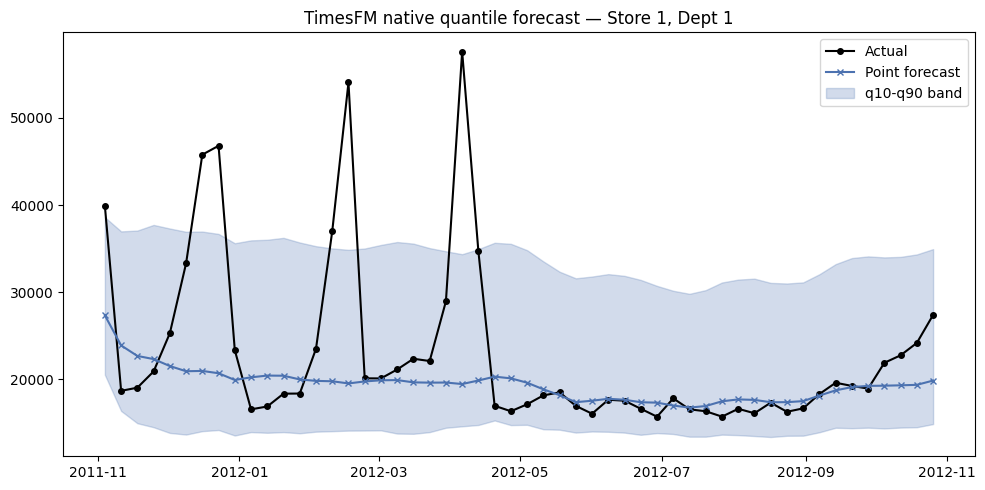

In [19]:
sample_key = (1, 1)
test_dates, test_actual, sample_point, sample_quantiles = quantile_rows[sample_key]
sample_point = np.clip(sample_point, 0, None)
sample_quantiles = np.clip(sample_quantiles, 0, None)

# quantile_rows' quantiles are the model's 10 output quantile levels; use the
# widest (q10/q90, indices 1 and 9 -- index 0 is the mean channel per the
# package's convention) and the median (index 5) for a clean band + line.
q10, q50, q90 = sample_quantiles[:, 1], sample_quantiles[:, 5], sample_quantiles[:, 9]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_dates, test_actual, label='Actual', marker='o', markersize=4, color='black')
ax.plot(test_dates, sample_point, label='Point forecast', marker='x', markersize=4, color='#4C72B0')
ax.fill_between(test_dates, q10, q90, alpha=0.25, color='#4C72B0', label='q10-q90 band')
ax.set_title(f'TimesFM native quantile forecast — Store {sample_key[0]}, Dept {sample_key[1]}')
ax.legend()
plt.tight_layout()
plt.savefig('plots/quantile_forecast_timesfm.png', dpi=150)
plt.show()

**Plot 3 — WMAE by stage**: baseline (shortest safe context) vs. best context length (CV) vs. final holdout.

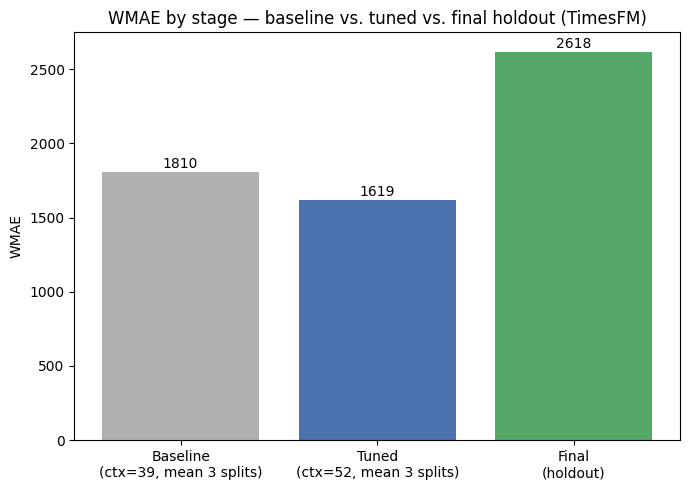

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
stages = [f'Baseline\n(ctx={CONTEXT_OPTIONS[0]}, mean 3 splits)', f'Tuned\n(ctx={best_context_length}, mean 3 splits)', 'Final\n(holdout)']
values = [baseline_val_wmae, tuned_val_wmae, holdout_wmae]
colors = ['#B0B0B0', '#4C72B0', '#55A868']
ax.bar(stages, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.01, f'{v:.0f}', ha='center')
ax.set_ylabel('WMAE')
ax.set_title('WMAE by stage — baseline vs. tuned vs. final holdout (TimesFM)')
plt.tight_layout()
plt.savefig('plots/wmae_by_fold_timesfm.png', dpi=150)
plt.show()

**Plot 4 — Residual distribution** on the local-test holdout.

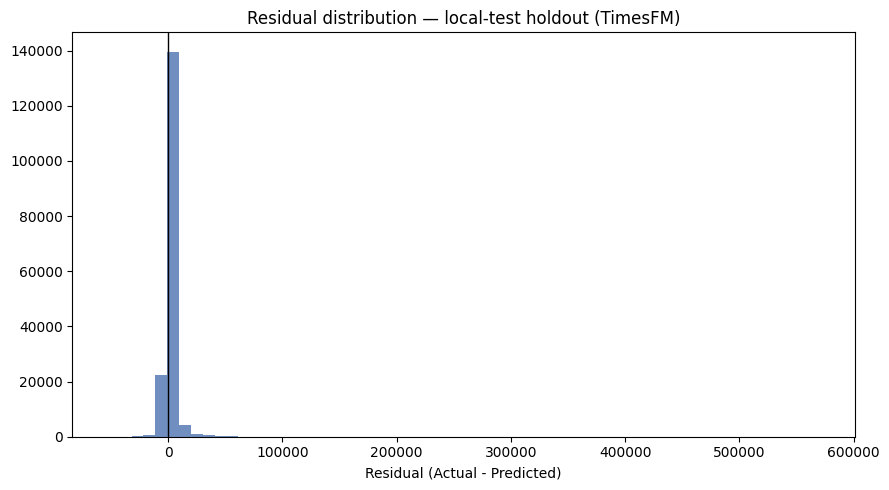

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pred_df['Residual'], bins=60, color='#4C72B0', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_title('Residual distribution — local-test holdout (TimesFM)')
plt.tight_layout()
plt.savefig('plots/residual_distribution_timesfm.png', dpi=150)
plt.show()

**Plot 5 — Actual vs. predicted, holiday vs. non-holiday weeks**

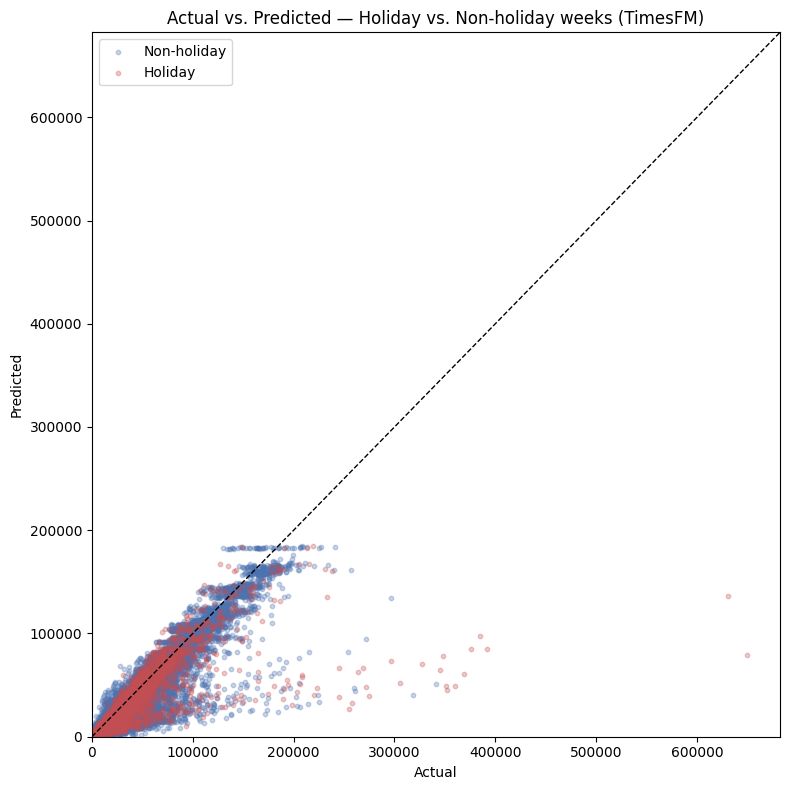

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
for is_holiday, color, label in [(False, '#4C72B0', 'Non-holiday'), (True, '#C44E52', 'Holiday')]:
    sub = pred_df[pred_df['IsHoliday'] == is_holiday]
    ax.scatter(sub['Actual'], sub['Predicted'], alpha=0.3, s=10, color=color, label=label)
lims = [0, pred_df[['Actual', 'Predicted']].to_numpy().max() * 1.05]
ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Actual vs. Predicted — Holiday vs. Non-holiday weeks (TimesFM)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_holiday_timesfm.png', dpi=150)
plt.show()

<a id='8'></a>
## 8. Full Pipeline

`utils.timesfm_model.TimesFMForecastPipeline`: bare `Store/Dept/Date`
rows in (no `IsHoliday` needed at all — no covariates), `Weekly_Sales`
predictions out. `fit()` just remembers each series' full history as
future context (nothing is trained), same raw-input contract as
`DLinearForecastPipeline`/`TFTForecastPipeline`/`PatchTSTForecastPipeline`.

In [23]:
full_pipeline = TimesFMForecastPipeline(tfm, context_length=best_context_length, horizon=HORIZON_FINAL)
full_pipeline.fit(train)
print('TimesFMForecastPipeline fit on all of train.csv (i.e. remembered full history; nothing trained).')

TimesFMForecastPipeline fit on all of train.csv (i.e. remembered full history; nothing trained).


**Confirm it truly takes raw input**: predict on bare rows straight from
`test.csv` — unmerged, no history/lag/rolling computed by the caller, and
no `IsHoliday` column needed at all.

In [24]:
raw_sample = test.head(5)
print('Raw input columns (exactly test.csv, nothing pre-computed):', raw_sample.columns.tolist())

raw_preds = full_pipeline.predict(raw_sample[['Store', 'Dept', 'Date']])
print()
print('Predictions:', raw_preds)

Raw input columns (exactly test.csv, nothing pre-computed): ['Store', 'Dept', 'Date', 'IsHoliday']

Predictions: [25074.44335938 22894.22265625 22471.67578125 22661.42382812
 22394.05273438]


**Save to MLflow (DagsHub model registry)** inside `TimesFM_Final_Fit`.
`mlflow.pyfunc`, same reasoning as every other notebook.

In [25]:
from mlflow.models import infer_signature


class TimesFMPyfuncWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def predict(self, context, model_input, params=None):
        return self.pipeline.predict(model_input)


signature = infer_signature(raw_sample[['Store', 'Dept', 'Date']], raw_preds)

with mlflow.start_run(run_name='TimesFM_Final_Fit'):
    mlflow.log_param('checkpoint', CHECKPOINT)
    mlflow.log_param('context_length', best_context_length)
    mlflow.log_param('horizon_final', HORIZON_FINAL)
    mlflow.log_metric('local_test_holdout_wmae', holdout_wmae)
    mlflow.log_metric('n_series_trained', len(full_pipeline.history_))

    mlflow.pyfunc.log_model(
        artifact_path='model',
        python_model=TimesFMPyfuncWrapper(full_pipeline),
        signature=signature,
        input_example=raw_sample[['Store', 'Dept', 'Date']],
    )

print('TimesFM_Final_Fit run logged, pipeline saved to MLflow model registry.')

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/doc

🏃 View run TimesFM_Final_Fit at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5/runs/b0fc3854267b4608948a1e312f2f2739
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/5
TimesFM_Final_Fit run logged, pipeline saved to MLflow model registry.


**Also save locally** under `models/` — but unlike DLinear/TFT/PatchTST,
there's no learned `state_dict` to save at all. TimesFM's weights are the
frozen, versioned `google/timesfm-2.5-200m-pytorch` checkpoint,
re-downloaded (cached by `huggingface_hub`) rather than reproduced from a
local file — so "saving the pipeline" here means saving just the config
(`context_length`, `horizon`) plus the raw history
`TimesFMForecastPipeline` needs, via `joblib`, same convention TFT uses
for its non-tensor pipeline state.

In [26]:
import os
import joblib

os.makedirs('models', exist_ok=True)
joblib.dump({
    'checkpoint': CHECKPOINT,
    'context_length': best_context_length,
    'horizon': HORIZON_FINAL,
    'history_': full_pipeline.history_,
    'last_date_': full_pipeline.last_date_,
}, 'models/timesfm_pipeline_state.joblib')
print('Saved to models/timesfm_pipeline_state.joblib (config + history only -- no model weights, see above)')

Saved to models/timesfm_pipeline_state.joblib (config + history only -- no model weights, see above)


In [27]:
state = joblib.load('models/timesfm_pipeline_state.joblib')

reloaded_pipeline = TimesFMForecastPipeline(tfm, context_length=state['context_length'], horizon=state['horizon'])
reloaded_pipeline.history_ = state['history_']
reloaded_pipeline.last_date_ = state['last_date_']

reloaded_preds = reloaded_pipeline.predict(raw_sample[['Store', 'Dept', 'Date']])
print('Reloaded-pipeline predictions match:', np.allclose(reloaded_preds, raw_preds))

Reloaded-pipeline predictions match: True
